In [ ]:
# === Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

# === Import Library ===
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Path ke folder dataset kamu ===
folder_path = '/content/drive/MyDrive/prakpola/'  # ganti dengan path folder kamu

In [ ]:
# === Load Dataset (Pilih Salah Satu) ===
df1 = pd.read_csv(folder_path + 'dataset1.csv')
df2 = pd.read_csv(folder_path + 'dataset2.csv')
print("kolom di df1:", df1.columns)
print("kolom di df2:", df2.columns)
merged_df = pd.merge(df1, df2, left_on='nama_mahasiswa', right_on='nama_mahasiswa', how='inner')
print("==== Dataset Sebelum Preprocessing ====")
display(merged_df.head())

kolom di df1: Index(['nama_mahasiswa', 'mata_kuliah', 'nilai'], dtype='object')
kolom di df2: Index(['nama_mahasiswa', 'Matematika', 'Bahasa Indonesia', 'Bahasa Inggris',
       'Kimia', 'Fisika'],
      dtype='object')
==== Dataset Sebelum Preprocessing ====


,nama_mahasiswa,mata_kuliah,nilai,Matematika,Bahasa Indonesia,Bahasa Inggris,Kimia,Fisika


In [ ]:
df = pd.concat([df1, df2], axis=0)
print("==== Dataset Sebelum Preprocessing ====")
display(df.head())

==== Dataset Sebelum Preprocessing ====


,nama_mahasiswa,mata_kuliah,nilai,Matematika,Bahasa Indonesia,Bahasa Inggris,Kimia,Fisika
0,John Doe,Matematika,80.0,NaN,NaN,NaN,NaN,NaN
1,John Doe,Fisika,85.0,NaN,NaN,NaN,NaN,NaN
2,John Doe,Kalkulus,75.0,NaN,NaN,NaN,NaN,NaN
3,John Doe,Algoritma dan Pemrograman,NaN,NaN,NaN,NaN,NaN,NaN
4,John Doe,Struktur Data,90.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# === Langkah 1: Handling Missing Values ===
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Imputasi nilai numerik dengan mean
imputer_num = SimpleImputer(strategy='mean')
df[num_cols] = imputer_num.fit_transform(df[num_cols])
print("==== Setelah Imputasi Nilai Numerik ====")
display(df[num_cols].head())

==== Setelah Imputasi Nilai Numerik ====


,nilai,Matematika,Bahasa Indonesia,Bahasa Inggris,Kimia,Fisika
0,80.000000,85.0,83.5,86.0,83.5,80.333333
1,85.000000,85.0,83.5,86.0,83.5,80.333333
2,75.000000,85.0,83.5,86.0,83.5,80.333333
3,84.423077,85.0,83.5,86.0,83.5,80.333333
4,90.000000,85.0,83.5,86.0,83.5,80.333333


In [ ]:
# Imputasi nilai kategorik dengan modus
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])
print("==== Setelah Imputasi Nilai Kategorik ====")
display(df[cat_cols].head())

==== Setelah Imputasi Nilai Kategorik ====


,nama_mahasiswa,mata_kuliah
0,John Doe,Matematika
1,John Doe,Fisika
2,John Doe,Kalkulus
3,John Doe,Algoritma dan Pemrograman
4,John Doe,Struktur Data


In [ ]:
# === Langkah 2: Encoding Data Kategorik ===
df_encoded = pd.get_dummies(df, columns=cat_cols)
print("==== Setelah Encoding Kategorik ====")
display(df_encoded.head())

==== Setelah Encoding Kategorik ====


,nilai,Matematika,Bahasa Indonesia,Bahasa Inggris,Kimia,Fisika,nama_mahasiswa_Alice Smith,nama_mahasiswa_Anna Tan,nama_mahasiswa_Bob Johnson,nama_mahasiswa_Daniel Kim,...,mata_kuliah_Algoritma dan Pemrograman,mata_kuliah_Database,mata_kuliah_Fisika,mata_kuliah_Jaringan Komputer,mata_kuliah_Kalkulus,mata_kuliah_Kecerdasan Buatan,mata_kuliah_Matematika,mata_kuliah_Pemrograman Web,mata_kuliah_Rekayasa Perangkat Lunak,mata_kuliah_Struktur Data
0,80.000000,85.0,83.5,86.0,83.5,80.333333,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,85.000000,85.0,83.5,86.0,83.5,80.333333,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,75.000000,85.0,83.5,86.0,83.5,80.333333,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,84.423077,85.0,83.5,86.0,83.5,80.333333,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,90.000000,85.0,83.5,86.0,83.5,80.333333,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# === Langkah 3: Normalisasi Data ===
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
print("==== Setelah Normalisasi Data Numerik ====")
display(df_encoded[num_cols].head())

==== Setelah Normalisasi Data Numerik ====


,nilai,Matematika,Bahasa Indonesia,Bahasa Inggris,Kimia,Fisika
0,-0.760470,0.0,0.0,0.0,0.0,0.0
1,0.099192,0.0,0.0,0.0,0.0,0.0
2,-1.620132,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.958853,0.0,0.0,0.0,0.0,0.0


In [ ]:
# === Tampilkan Hasil Preprocessing ===
print("==== Dataset Setelah Preprocessing Lengkap ====")
display(df_encoded.head())

==== Dataset Setelah Preprocessing Lengkap ====


,nilai,Matematika,Bahasa Indonesia,Bahasa Inggris,Kimia,Fisika,nama_mahasiswa_Alice Smith,nama_mahasiswa_Anna Tan,nama_mahasiswa_Bob Johnson,nama_mahasiswa_Daniel Kim,...,mata_kuliah_Algoritma dan Pemrograman,mata_kuliah_Database,mata_kuliah_Fisika,mata_kuliah_Jaringan Komputer,mata_kuliah_Kalkulus,mata_kuliah_Kecerdasan Buatan,mata_kuliah_Matematika,mata_kuliah_Pemrograman Web,mata_kuliah_Rekayasa Perangkat Lunak,mata_kuliah_Struktur Data
0,-0.760470,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.099192,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,-1.620132,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,0.000000,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,0.958853,0.0,0.0,0.0,0.0,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


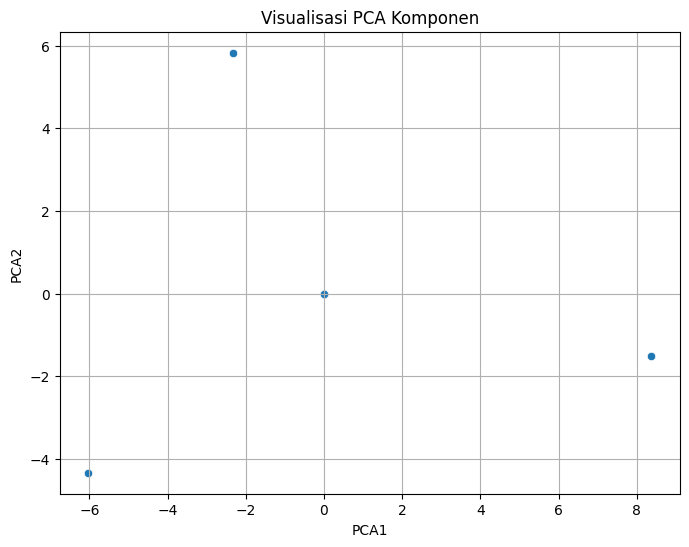

In [ ]:
# === Langkah 4: PCA untuk Reduksi Dimensi ===
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_encoded)
df_encoded['PCA1'] = pca_result[:, 0]
df_encoded['PCA2'] = pca_result[:, 1]
# === Visualisasi Hasil PCA ===
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', data=df_encoded)
plt.title('Visualisasi PCA Komponen')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.show()

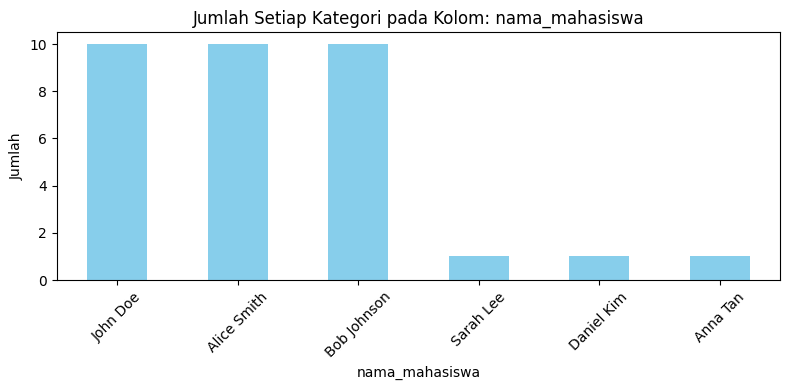

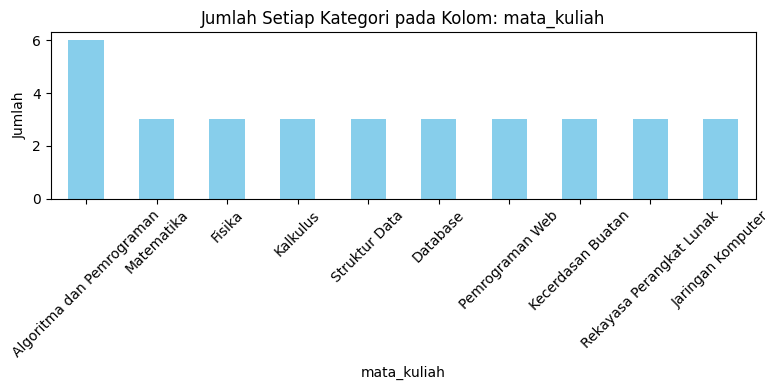

In [ ]:
# === Visualisasi Grafik Batang (Kategori vs Jumlah) ===
if len(cat_cols) > 0:
    for col in cat_cols:
        plt.figure(figsize=(8, 4))
        df[col].value_counts().plot(kind='bar', color='skyblue')
        plt.title(f'Jumlah Setiap Kategori pada Kolom: {col}')
        plt.xlabel(col)
        plt.ylabel('Jumlah')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()